# 1. Teil: Bilder verstehen
## Wie speichert der Computer Bilder?

In diesem Notebook werden wir lernen, wie digitale Bilder gespeichert sind und mit dem MNIST-Datensatz arbeiten.

Das Schachbrett als Zahlen:
[[1 0 1 0]
 [0 1 0 1]
 [1 0 1 0]
 [0 1 0 1]]


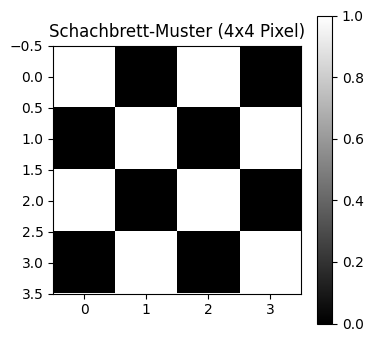

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Ein einfaches 4x4 Schachbrett-Muster als Zahlen
schachbrett = np.array([
    [1, 0, 1, 0],
    [0, 1, 0, 1],
    [1, 0, 1, 0],
    [0, 1, 0, 1]
])

print("Das Schachbrett als Zahlen:")
print(schachbrett)

# Das Bild anzeigen
plt.figure(figsize=(4, 4))
plt.imshow(schachbrett, cmap='gray')
plt.title('Schachbrett-Muster (4x4 Pixel)')
plt.colorbar()
plt.show()

## 1. Ein einfaches Schwarzweiß-Bild

## 2. Graustufenbilder (0-255)

Graustufenbild (0-255):
[[  0  64 128 192]
 [ 32  96 160 224]
 [ 64 128 192 255]
 [ 96 160 224 255]]


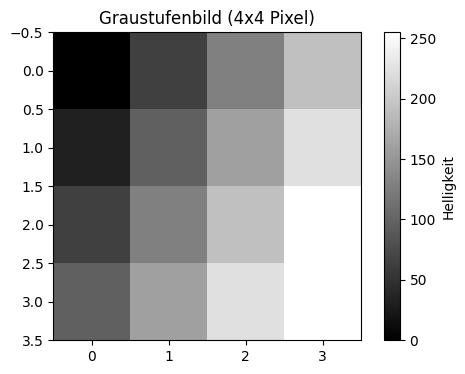


Minimum: 0 (schwarz)
Maximum: 255 (weiß)
Durchschnitt: 141.9


In [2]:
# Ein Graustufenbild - Werte von 0 (schwarz) bis 255 (weiß)
graustufen = np.array([
    [0, 64, 128, 192],
    [32, 96, 160, 224],
    [64, 128, 192, 255],
    [96, 160, 224, 255]
])

print("Graustufenbild (0-255):")
print(graustufen)

# Anzeigen
plt.figure(figsize=(6, 4))
plt.imshow(graustufen, cmap='gray', vmin=0, vmax=255)
plt.title('Graustufenbild (4x4 Pixel)')
plt.colorbar(label='Helligkeit')
plt.show()

print(f"\nMinimum: {graustufen.min()} (schwarz)")
print(f"Maximum: {graustufen.max()} (weiß)")
print(f"Durchschnitt: {graustufen.mean():.1f}")

## 3. Farbbilder (RGB)

RGB-Bild Form: (4, 4, 3)
Pixel [0,0]: [255   0   0] (Rot)
Pixel [0,2]: [  0 255   0] (Grün)
Pixel [2,0]: [  0   0 255] (Blau)
Pixel [2,2]: [255 255   0] (Gelb)


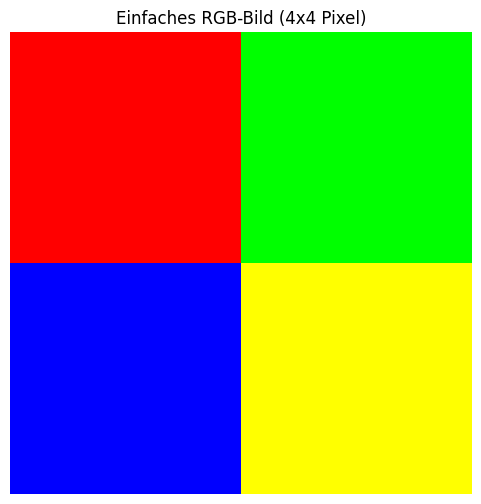

In [3]:
# RGB-Bild: Jedes Pixel hat 3 Werte (Rot, Grün, Blau)
# Shape: (Höhe, Breite, 3 Kanäle)

rgb_bild = np.zeros((4, 4, 3), dtype=np.uint8)

# Ein rotes Quadrat oben links
rgb_bild[0:2, 0:2] = [255, 0, 0]  # Rot

# Ein grünes Quadrat oben rechts
rgb_bild[0:2, 2:4] = [0, 255, 0]  # Grün

# Ein blaues Quadrat unten links
rgb_bild[2:4, 0:2] = [0, 0, 255]  # Blau

# Ein gelbes Quadrat unten rechts
rgb_bild[2:4, 2:4] = [255, 255, 0]  # Gelb

print("RGB-Bild Form:", rgb_bild.shape)
print("Pixel [0,0]:", rgb_bild[0, 0], "(Rot)")
print("Pixel [0,2]:", rgb_bild[0, 2], "(Grün)")
print("Pixel [2,0]:", rgb_bild[2, 0], "(Blau)")
print("Pixel [2,2]:", rgb_bild[2, 2], "(Gelb)")

# Anzeigen
plt.figure(figsize=(6, 6))
plt.imshow(rgb_bild)
plt.title('Einfaches RGB-Bild (4x4 Pixel)')
plt.axis('off')
plt.show()

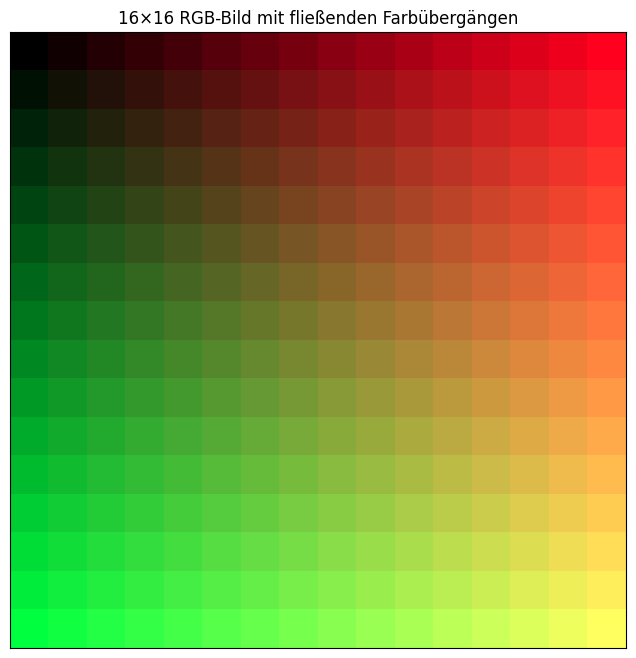

In [43]:
import numpy as np
import matplotlib.pyplot as plt

# 16x16 RGB image
size = 16
rgb_bild = np.zeros((size, size, 3), dtype=np.uint8)

for y in range(size):
    for x in range(size):
        r = int(255 * x / (size - 1))                 # Red increases left -> right
        g = int(255 * y / (size - 1))                 # Green increases top -> bottom
        b = int(255 * (x / 4 + y / 2) / (2 * (size - 1)))     # Blue changes smoothly

        rgb_bild[y, x] = [r, g, b]

plt.figure(figsize=(8, 8))
plt.imshow(rgb_bild, interpolation="nearest")
plt.title("16×16 RGB-Bild mit fließenden Farbübergängen")
plt.xticks([])
plt.yticks([])
plt.show()

## 4. MNIST-Daten laden und erkunden

In [4]:
from tensorflow import keras

# MNIST-Daten laden
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("MNIST Datensatz Informationen:")
print(f"Training Bilder: {x_train.shape}")
print(f"Training Labels: {y_train.shape}")
print(f"Test Bilder: {x_test.shape}")
print(f"Test Labels: {y_test.shape}")

print(f"\nPixel-Werte: min={x_train.min()}, max={x_train.max()}")
print(f"Erste 20 Labels: {y_train[:20]}")

I0000 00:00:1784462650.930369   14949 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784462651.394575   14949 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784462653.999566   14949 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


MNIST Datensatz Informationen:
Training Bilder: (60000, 28, 28)
Training Labels: (60000,)
Test Bilder: (10000, 28, 28)
Test Labels: (10000,)

Pixel-Werte: min=0, max=255
Erste 20 Labels: [5 0 4 1 9 2 1 3 1 4 3 5 3 6 1 7 2 8 6 9]


## 5. Ein einzelnes MNIST-Bild analysieren

Bild Index: 0
Label (echte Ziffer): 5
Bild-Form: (28, 28)

Die ersten 10 Pixel-Werte der ersten Zeile:
[0 0 0 0 0 0 0 0 0 0]


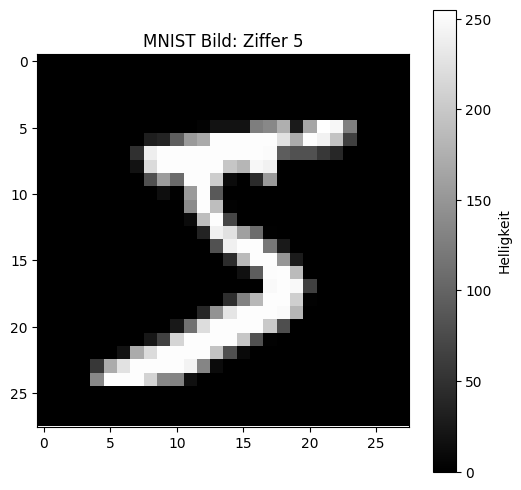

In [5]:
# Ein einzelnes Bild anschauen
index = 0
bild = x_train[index]
label = y_train[index]

print(f"Bild Index: {index}")
print(f"Label (echte Ziffer): {label}")
print(f"Bild-Form: {bild.shape}")
print(f"\nDie ersten 10 Pixel-Werte der ersten Zeile:")
print(bild[0, :10])

# Das ganze Bild anzeigen
plt.figure(figsize=(6, 6))
plt.imshow(bild, cmap='gray')
plt.title(f'MNIST Bild: Ziffer {label}')
plt.colorbar(label='Helligkeit')
plt.show()

## 6. Mehrere MNIST-Bilder vergleichen

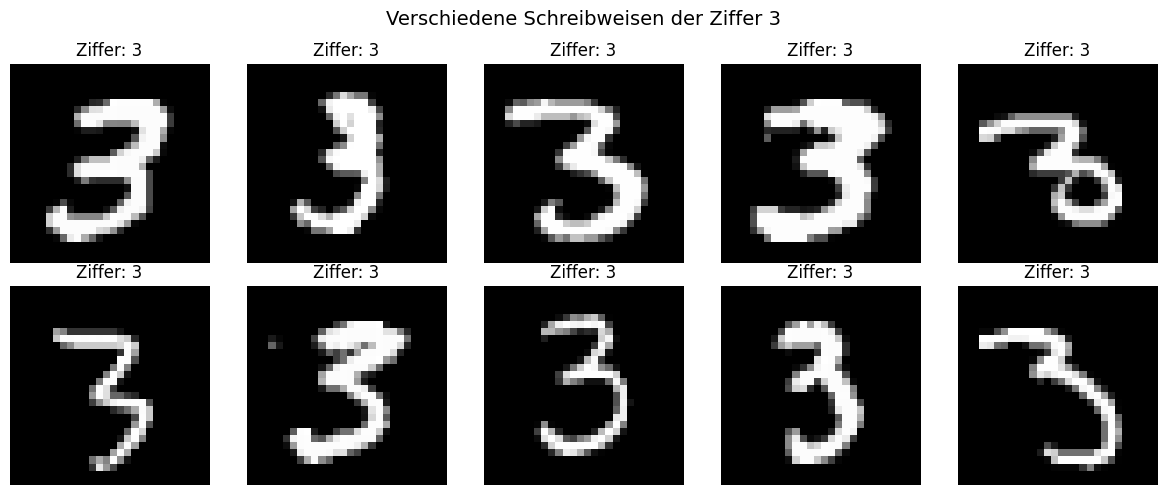

Beobachtung: Alle sind Ziffern 3, aber die Schreibweise ist unterschiedlich!


In [6]:
# Mehrere Ziffern einer Klasse anschauen (z.B. alle 3er)
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

# Finde die ersten 10 Ziffern "3"
indices_3 = np.where(y_train == 3)[0][:10]

for i, idx in enumerate(indices_3):
    ax = axes[i // 5, i % 5]
    ax.imshow(x_train[idx], cmap='gray')
    ax.set_title(f'Ziffer: 3')
    ax.axis('off')

plt.suptitle('Verschiedene Schreibweisen der Ziffer 3', fontsize=14)
plt.tight_layout()
plt.show()

print(f"Beobachtung: Alle sind Ziffern 3, aber die Schreibweise ist unterschiedlich!")

## 7. Bild-Statistiken

In [7]:
# Statistiken / Merkmale für verschiedene Ziffern
print("Zusammengefasste Merkmale verschiedener Ziffern")
print("="*60)

threshold = 100

metrics = []
center_variances = []

for digit in range(10):
    indices = np.where(y_train == digit)[0]
    bilder = x_train[indices]

    # Durchschnittliche Helligkeit
    durchschnitt = bilder.mean()

    # Standardabweichung der Pixelwerte
    std = bilder.std()

    # Anzahl dunkler Pixel
    dunkle_pixel = (bilder < threshold).sum(axis=(1,2)).mean()

    # Schwerpunkt für jedes einzelne Bild
    y_coords, x_coords = np.indices((28, 28))

    gewicht = bilder.sum(axis=(1,2))

    center_x = (
        (bilder * x_coords).sum(axis=(1,2)) / gewicht
    )

    center_y = (
        (bilder * y_coords).sum(axis=(1,2)) / gewicht
    )

    # Mittelwerte
    mean_x = center_x.mean()
    mean_y = center_y.mean()

    # Standardabweichung der Positionen
    std_x = center_x.std()
    std_y = center_y.std()

    metrics.append([
        durchschnitt,
        std,
        dunkle_pixel,
        mean_x,
        mean_y
    ])

    center_variances.append([
        std_x,
        std_y
    ])

    print(
        f"Ziffer {digit}: "
        f"Schwerpunkt=({mean_x:.1f},{mean_y:.1f}), "
        f"Streuung=({std_x:.1f},{std_y:.1f})"
    )


metrics = np.array(metrics)
center_variances = np.array(center_variances)

Zusammengefasste Merkmale verschiedener Ziffern
Ziffer 0: Schwerpunkt=(14.0,14.0), Streuung=(0.3,0.3)
Ziffer 1: Schwerpunkt=(14.0,14.0), Streuung=(0.3,0.3)
Ziffer 2: Schwerpunkt=(14.0,14.0), Streuung=(0.3,0.3)
Ziffer 3: Schwerpunkt=(14.0,14.0), Streuung=(0.3,0.3)
Ziffer 4: Schwerpunkt=(14.0,14.0), Streuung=(0.3,0.3)
Ziffer 5: Schwerpunkt=(14.0,14.0), Streuung=(0.3,0.3)
Ziffer 6: Schwerpunkt=(14.0,14.0), Streuung=(0.3,0.3)
Ziffer 7: Schwerpunkt=(14.0,14.0), Streuung=(0.3,0.3)
Ziffer 8: Schwerpunkt=(14.0,14.0), Streuung=(0.3,0.3)
Ziffer 9: Schwerpunkt=(14.0,14.0), Streuung=(0.3,0.3)


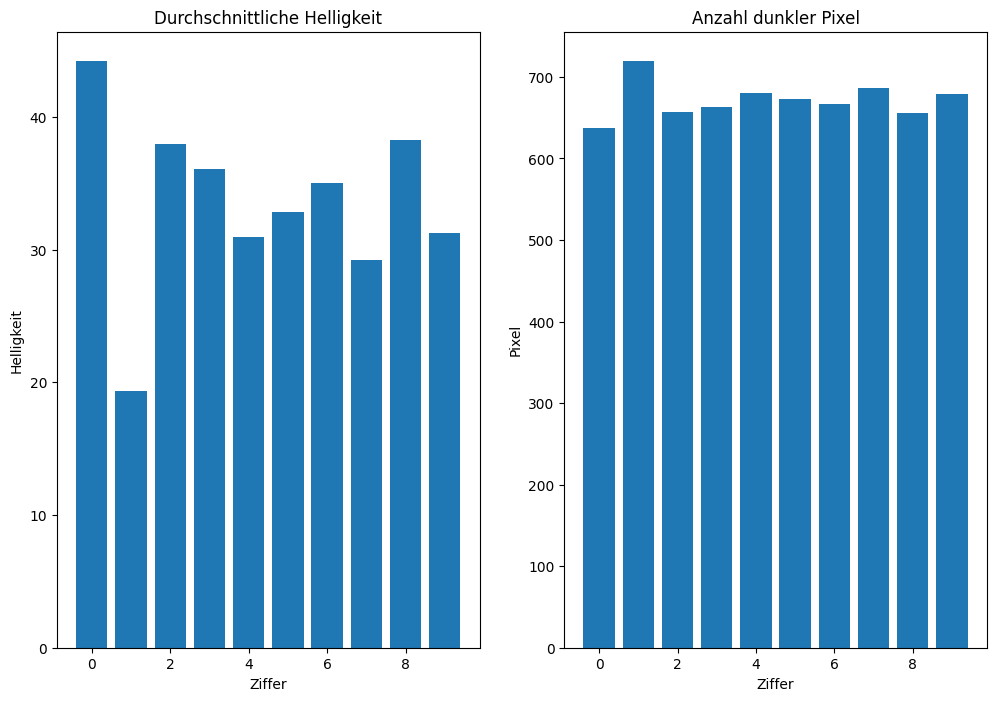

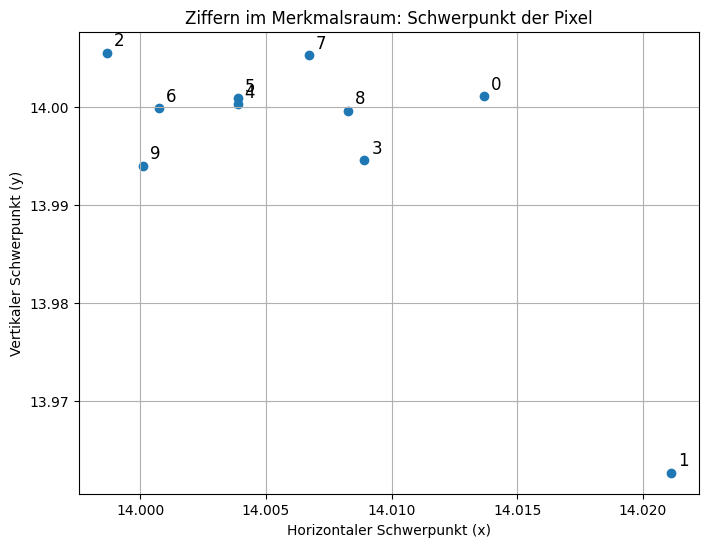

<Figure size 640x480 with 0 Axes>

In [8]:
# -------------------------------------------------
# Visualisierung
# -------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 8))


# Durchschnittliche Helligkeit
axes[0].bar(range(10), metrics[:,0])
axes[0].set_title("Durchschnittliche Helligkeit")
axes[0].set_xlabel("Ziffer")
axes[0].set_ylabel("Helligkeit")


# Anzahl dunkler Pixel
axes[1].bar(range(10), metrics[:,2])
axes[1].set_title("Anzahl dunkler Pixel")
axes[1].set_xlabel("Ziffer")
axes[1].set_ylabel("Pixel")


# -------------------------------------------------
# Visualisierung: Schwerpunkt als 2D Feature Space
# -------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    metrics[:, 3],   # horizontaler Schwerpunkt
    metrics[:, 4],   # vertikaler Schwerpunkt
)

for digit in range(10):
    plt.annotate(
        str(digit),
        (metrics[digit, 3], metrics[digit, 4]),
        fontsize=12,
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Horizontaler Schwerpunkt (x)")
plt.ylabel("Vertikaler Schwerpunkt (y)")
plt.title("Ziffern im Merkmalsraum: Schwerpunkt der Pixel")

plt.grid(True)
plt.show()


plt.suptitle(
    "Zusammengefasste Merkmale verschiedener Ziffern",
    fontsize=14
)

plt.tight_layout()
plt.show()

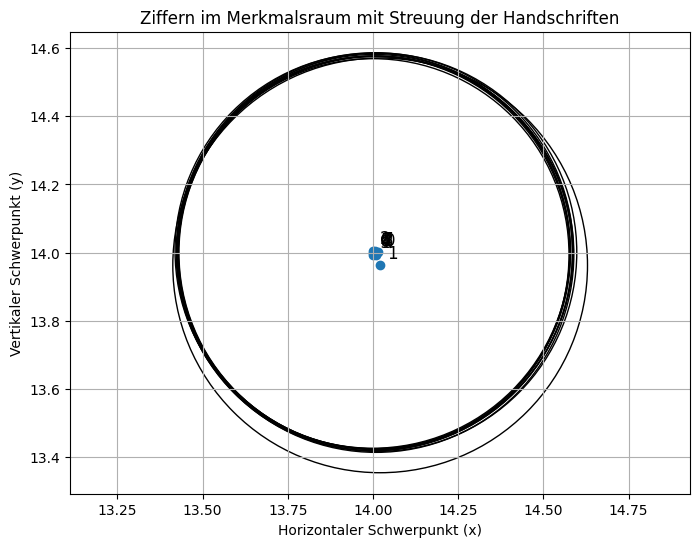

In [9]:
# -------------------------------------------------
# Visualisierung: Schwerpunkt mit Streuung
# -------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    metrics[:, 3],
    metrics[:, 4],
)

ax = plt.gca()

for digit in range(10):

    x = metrics[digit, 3]
    y = metrics[digit, 4]

    # Größe der Ellipse aus Standardabweichungen
    width = 2 * center_variances[digit, 0]
    height = 2 * center_variances[digit, 1]

    ellipse = plt.Circle(
        (x, y),
        radius=max(width, height),
        fill=False
    )

    ax.add_patch(ellipse)

    plt.annotate(
        str(digit),
        (x, y),
        fontsize=12,
        xytext=(5,5),
        textcoords="offset points"
    )


plt.xlabel("Horizontaler Schwerpunkt (x)")
plt.ylabel("Vertikaler Schwerpunkt (y)")
plt.title(
    "Ziffern im Merkmalsraum mit Streuung der Handschriften"
)

plt.grid(True)
plt.axis("equal")

plt.show()

## 8. Durchschnittliche Ziffern visualisieren

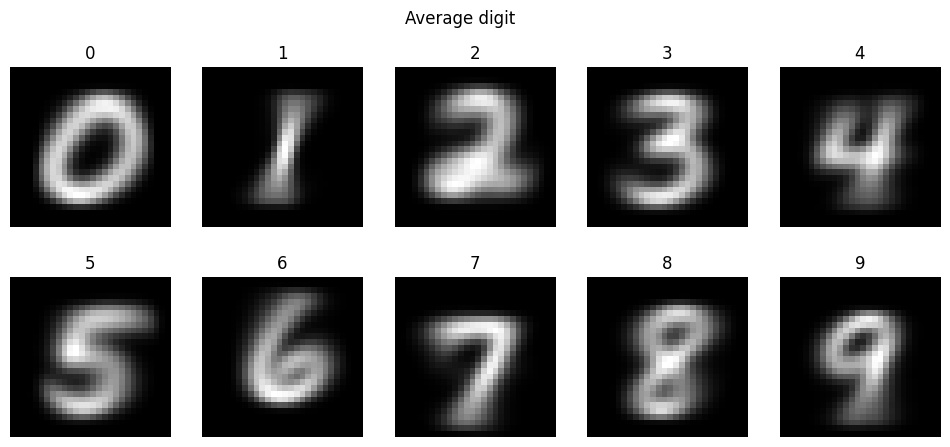

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras

# Load MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Convert to float
x_train = x_train.astype(np.float32)
x_test = x_test.astype(np.float32)

# --------------------------------------------------
# Compute average image of every digit
# --------------------------------------------------

average_digits = np.zeros((10, 28, 28))

for digit in range(10):
    average_digits[digit] = x_train[y_train == digit].mean(axis=0)

# --------------------------------------------------
# Visualize
# --------------------------------------------------

fig, axes = plt.subplots(2, 5, figsize=(12,5))

for digit in range(10):
    ax = axes[digit//5, digit%5]
    ax.imshow(average_digits[digit], cmap="gray")
    ax.set_title(str(digit))
    ax.axis("off")

plt.suptitle("Average digit")
plt.show()

In [11]:
def predict(image, prototypes):
    # Euclidean distance
    distances = np.linalg.norm(prototypes - image, axis=(1,2))

    # Smaller distance -> larger probability
    scores = np.exp(-distances / 1000)

    probabilities = scores / scores.sum()

    prediction = np.argmax(probabilities)

    return prediction, probabilities

In [44]:
def test_number(idx):
    prediction, probs = predict(x_test[idx], average_digits)
    
    plt.imshow(256 - x_test[idx], cmap="gray")
    plt.title(f"Prediction: {prediction}   True: {y_test[idx]}")
    plt.axis("off")
    plt.show()
    
    print(probs)
    plt.figure(figsize=(10, 5))
    plt.bar(range(10), probs)
    plt.xlabel('Ziffer')
    plt.ylabel('Probability')
    plt.title('Prediction Probability')
    plt.xticks(range(10))
    plt.show()

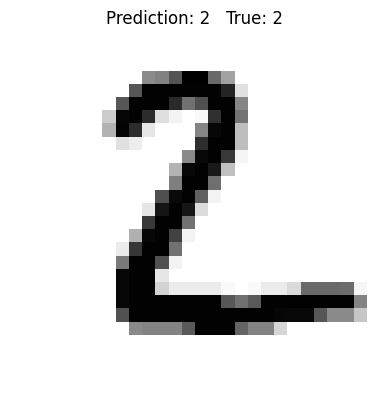

[0.090121   0.10155275 0.1228584  0.11822626 0.07814028 0.11553045
 0.11567731 0.07495584 0.10301061 0.0799271 ]


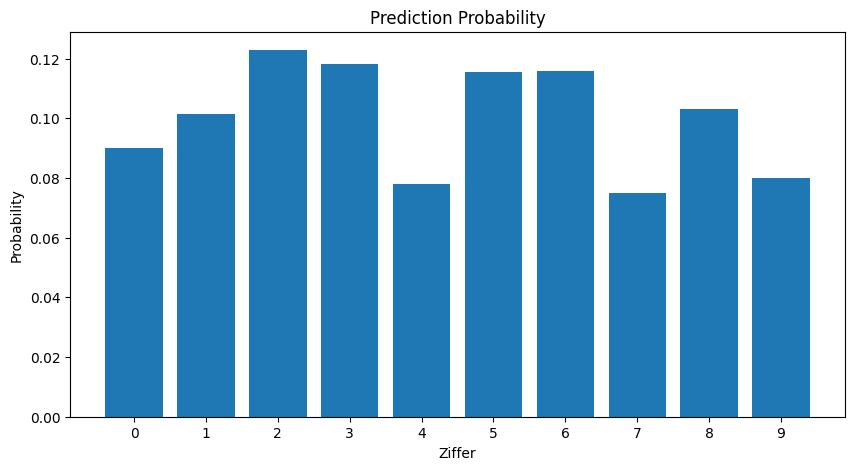

In [45]:
test_number(1)

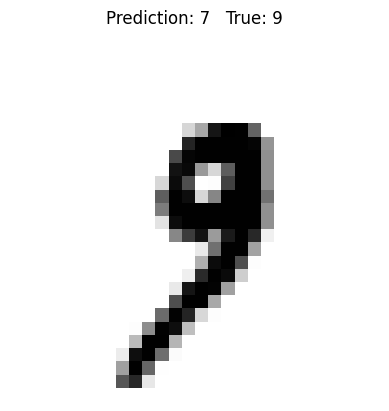

[0.05495512 0.1078205  0.08664711 0.10256896 0.10217078 0.1009599
 0.08040479 0.13594732 0.10197823 0.12654731]


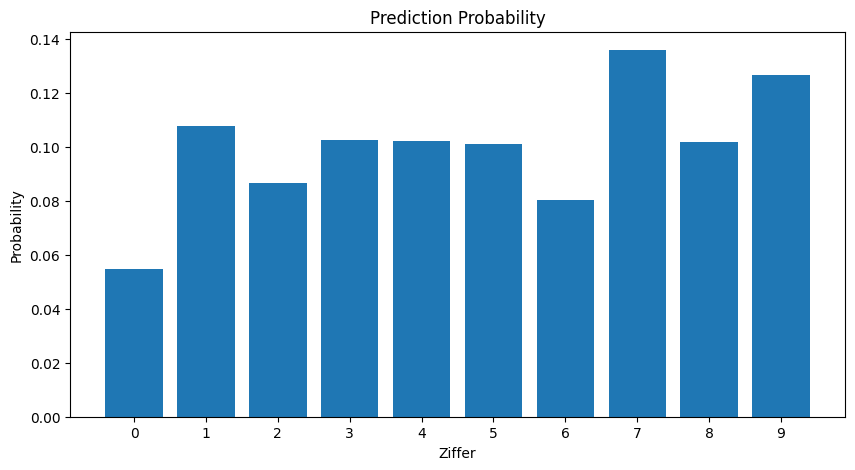

In [46]:
test_number(1000)

In [68]:
predictions = []

for image in x_test:
    pred, _ = predict(image, average_digits)
    predictions.append(pred)

predictions = np.array(predictions)

accuracy = np.mean(predictions == y_test)

print(f"Accuracy: {accuracy:.3f}")

Accuracy: 0.820


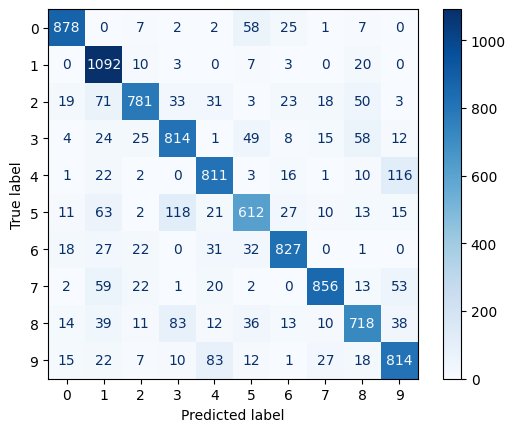

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, predictions)

disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap="Blues")
plt.show()

## Ein lernender Klassifikator: k-Nächste-Nachbarn

In [17]:
from sklearn.neighbors import KNeighborsClassifier

# Flatten images
X_train = x_train.reshape(len(x_train), -1)
X_test = x_test.reshape(len(x_test), -1)

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

accuracy = knn.score(X_test, y_test)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9688


In [65]:
def test_number_kNN(idx):
    distances, indices = knn.kneighbors([X_test[idx]], n_neighbors=5)
    print(distances) 
    plt.figure(figsize=(12,3))
    
    plt.subplot(1,6,1)
    plt.imshow(x_test[idx], cmap="gray")
    plt.title(f"Test\n{y_test[idx]}")
    plt.axis("off")
    
    for i, ind in enumerate(indices[0]):
        plt.subplot(1,6,i+2)
        plt.imshow(x_train[ind], cmap="gray")
        plt.title(y_train[ind])
        # plt.axis("off")
        plt.xlabel("d = " + str(int(distances[0][i])))
    
    plt.tight_layout()
    plt.show()

[[676.58404541 793.98675537 862.67663574 864.50390625 894.69995117]]


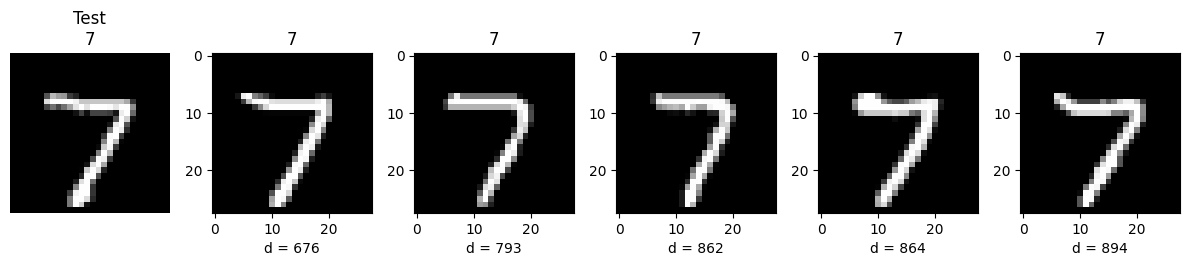

In [66]:
test_number_kNN(0)

[[1619.59191895 1643.7277832  1658.43847656 1670.09973145 1676.58459473]]


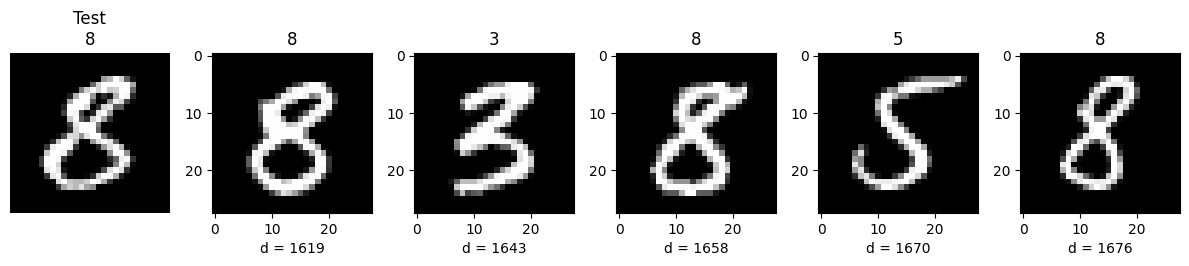

In [67]:
test_number_kNN(1234)

In [21]:
def nkk_confusionmatrix():
    predictions = []

    def predict_digit(image):
        image = image.reshape(1, -1)
        return knn.predict(image)[0]

    predictions = np.array([predict_digit(img) for img in x_test])

    cm = confusion_matrix(y_test, predictions)

    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap="Blues")
    plt.show()

In [22]:
# nkk_confusionmatrix()